In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import simulation_engine as engine

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Simulation 4 - Resource Efficiency (6-Player)

This simulation runs 10 000 games with six players and measures how resources flow through the game:

* **Resources consumed** - how many of each resource type (Wood, Stone, Rope) are spent on successful missions on average
* **Mission failure causes** - which resource type (or tool damage) most often prevents a mission from succeeding
* **Tool repair frequency** - how many times each tool (Knife, Vessel) is repaired per game on average

In [2]:
N_GAMES = 10_000
BASE_SEED = 200_000

records = engine.run_scenario(
    player_count = 6,
    n_games      = N_GAMES,
    base_seed    = BASE_SEED,
)

In [3]:
RESOURCES = list(engine.Resource)
TOOLS = list(engine.Tool)

rows = []
for i, record in enumerate(records):
    row = {
        "game_id":       i,
        "outcome":       record.outcome,
        "rounds_played": record.rounds_played,
        "is_win":        int(record.outcome == "win"),
        "mission_failures_any_extra": record.mission_failures_any_extra,
    }
    for resource in RESOURCES:
        row[f"consumed_{resource.name}"] = record.resources_consumed.get(resource, 0)
        row[f"failure_resource_{resource.name}"] = record.mission_failures_by_resource.get(resource, 0)
    for tool in TOOLS:
        row[f"failure_tool_{tool.name}"] = record.mission_failures_tool_damaged.get(tool, 0)
        row[f"repairs_{tool.name}"] = record.tool_repairs.get(tool, 0)
    rows.append(row)

data = pd.DataFrame(rows)

### Summary Table

Each row is one tracked metric. The table shows the mean and standard deviation across all 10 000 games.

| Column group | What it shows |
|---|---|
| `consumed_*` | Resources spent on successful missions per game |
| `failure_resource_*` | Times a shortage of that resource caused a mission failure |
| `failure_tool_*` | Times a damaged tool blocked a mission |
| `failure_any_extra` | Times the wildcard resource shortfall caused a mission failure |
| `repairs_*` | Number of times each tool was repaired per game |

In [4]:
consumed_cols = [f"consumed_{r.name}" for r in RESOURCES]
failure_resource_cols = [f"failure_resource_{r.name}" for r in RESOURCES]
failure_tool_cols = [f"failure_tool_{t.name}" for t in TOOLS]
repair_cols = [f"repairs_{t.name}" for t in TOOLS]

all_metric_cols = consumed_cols + failure_resource_cols + ["mission_failures_any_extra"] + failure_tool_cols + repair_cols

summary_rows = []
for column in all_metric_cols:
    summary_rows.append({
        "metric": column,
        "mean":   round(data[column].mean(), 3),
        "std":    round(data[column].std(), 3),
    })

resource_summary = pd.DataFrame(summary_rows)
resource_summary

,metric,mean,std
0,consumed_WOOD,12.725,4.360
1,consumed_STONE,8.473,3.661
2,consumed_ROPE,12.811,4.583
3,failure_resource_WOOD,1.983,1.584
4,failure_resource_STONE,0.282,0.581
5,failure_resource_ROPE,2.637,1.996
6,mission_failures_any_extra,0.017,0.129
7,failure_tool_KNIFE,1.207,2.218
8,failure_tool_VESSEL,1.028,2.120
9,repairs_KNIFE,0.297,0.498


### Resources Consumed per Game

Average number of each resource type spent across successful missions per game. Error bars show one standard deviation.

This reveals which resources the group burns through most and whether the three resource types are consumed at similar rates or whether one dominates mission costs.

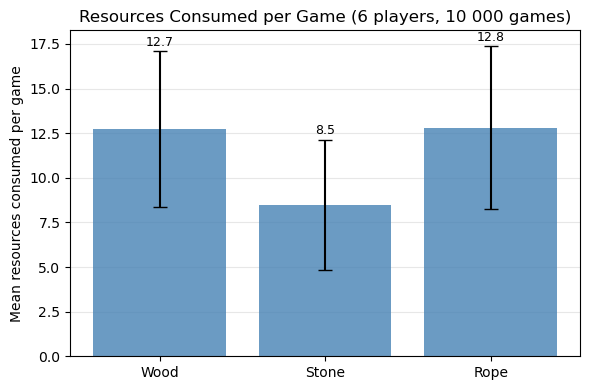

In [5]:
resource_labels = [r.name.title() for r in RESOURCES]
consumed_means = [data[f"consumed_{r.name}"].mean() for r in RESOURCES]
consumed_stds = [data[f"consumed_{r.name}"].std() for r in RESOURCES]

plt.figure(figsize = (6, 4))

plt.bar(
    resource_labels,
    consumed_means,
    yerr   = consumed_stds,
    color  = "steelblue",
    alpha  = 0.8,
    capsize = 5,
    zorder = 2,
)

for i, (mean, std) in enumerate(zip(consumed_means, consumed_stds)):
    plt.text(i, mean + std + 0.3, f"{mean:.1f}", ha = "center", fontsize = 9)

plt.ylabel("Mean resources consumed per game")
plt.title("Resources Consumed per Game (6 players, 10 000 games)")
plt.grid(axis = "y", alpha = 0.3, zorder = 0)

plt.tight_layout()
plt.show()

### Mission Failure Breakdown

How often each cause prevented a mission from succeeding, averaged per game. The causes are:

* **Resource shortage** - the group lacked enough of a specific typed resource (Wood, Stone, Rope)
* **Any-extra shortage** - typed requirements were all met, but the group had insufficient resources to cover the wildcard surcharge from the complication card
* **Tool damaged** - a required tool (Knife or Vessel) was broken and the mission could not start

Knowing the dominant failure cause guides strategy: if typed shortages dominate, the group should gather more of specific resources; if tool damage dominates, Craftsman repair should be prioritised.

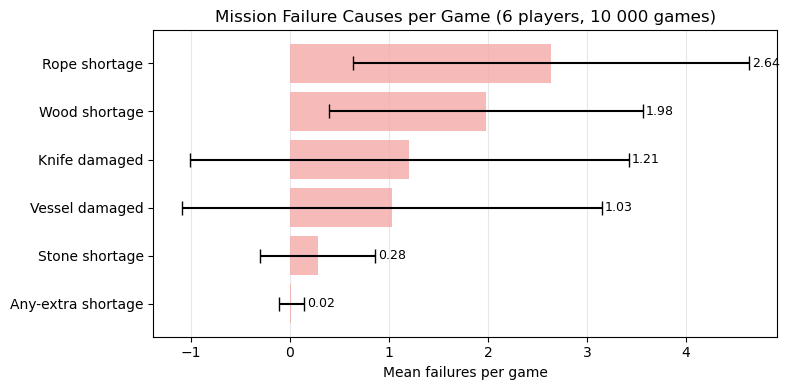

In [6]:
failure_labels = (
    [f"{r.name.title()} shortage" for r in RESOURCES]
    + ["Any-extra shortage"]
    + [f"{t.name.title()} damaged" for t in TOOLS]
)
failure_means = (
    [data[f"failure_resource_{r.name}"].mean() for r in RESOURCES]
    + [data["mission_failures_any_extra"].mean()]
    + [data[f"failure_tool_{t.name}"].mean() for t in TOOLS]
)
failure_stds = (
    [data[f"failure_resource_{r.name}"].std() for r in RESOURCES]
    + [data["mission_failures_any_extra"].std()]
    + [data[f"failure_tool_{t.name}"].std() for t in TOOLS]
)

sorted_pairs = sorted(
    zip(failure_labels, failure_means, failure_stds),
    key = lambda triple: triple[1],
)
failure_labels_sorted = [triple[0] for triple in sorted_pairs]
failure_means_sorted = [triple[1] for triple in sorted_pairs]
failure_stds_sorted = [triple[2] for triple in sorted_pairs]

plt.figure(figsize = (8, 4))

plt.barh(
    failure_labels_sorted,
    failure_means_sorted,
    xerr    = failure_stds_sorted,
    color   = "#f4a9a8",
    alpha   = 0.8,
    capsize = 5,
    zorder  = 2,
)

for i, (mean, std) in enumerate(zip(failure_means_sorted, failure_stds_sorted)):
    plt.text(mean + std + 0.03, i, f"{mean:.2f}", va = "center", fontsize = 9)

plt.xlabel("Mean failures per game")
plt.title("Mission Failure Causes per Game (6 players, 10 000 games)")
plt.grid(axis = "x", alpha = 0.3, zorder = 0)

plt.tight_layout()
plt.show()

### Tool Repair Frequency

Average number of times each tool (Knife and Vessel) is repaired per game, combining both delayed repairs (Craftsman spending Stone) and instant repairs (Gather Materials mission bonus). Error bars show one standard deviation.

A high repair count for one tool indicates it is damaged more often by complication cards or is more frequently required by missions, making it the more demanding resource sink for the group.

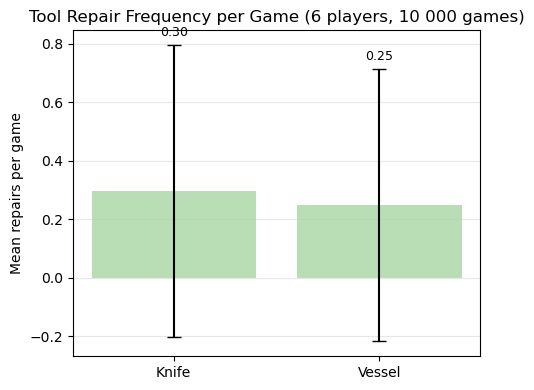

In [7]:
tool_labels = [t.name.title() for t in TOOLS]
repair_means = [data[f"repairs_{t.name}"].mean() for t in TOOLS]
repair_stds = [data[f"repairs_{t.name}"].std() for t in TOOLS]

plt.figure(figsize = (5, 4))

plt.bar(
    tool_labels,
    repair_means,
    yerr    = repair_stds,
    color   = "#a8d5a2",
    alpha   = 0.8,
    capsize = 5,
    zorder  = 2,
)

for i, (mean, std) in enumerate(zip(repair_means, repair_stds)):
    plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha = "center", fontsize = 9)

plt.ylabel("Mean repairs per game")
plt.title("Tool Repair Frequency per Game (6 players, 10 000 games)")
plt.grid(axis = "y", alpha = 0.3, zorder = 0)

plt.tight_layout()
plt.show()

### Results

* Stone is consumed less than Wood and Rope (~8.7 vs ~12.6 and ~12.8). Changing the resource ratio could be used to make the game harder. Most missions fail because of a lack of 1-2 Wood or Rope.
* Rope and Wood are consumed at almost the same rate but Rope causes more mission failures (2.62 vs 1.93 per game). This means Rope supply is tighter relative to its demand - missions need more Rope than the group can reliably gather.
* The extra resource rule isn't causing any meaningful failures (0.017 per game) so it has almost no effect on the game.
* Tools are repaired at roughly equal rates (Knife 0.30, Vessel 0.25 per game) meaning they are broken and used equally. Tool damage also blocks around 2.2 mission attempts per game (Knife 1.22, Vessel 1.03) but this counts every blocked attempt, not every breakage - one broken tool can block multiple missions across rounds before it gets repaired.
* Around 13 + 9 + 13 = ~35 resources are consumed per game which means the resource cards are a lot more than needed. This rule can be revised or mission resource requirements can be increased.